In [1]:
# ###------------VERSION 1---------------

import tensorflow as tf
import shap
import numpy as np
import cv2
import random
import os
import glob

# # --- 1️⃣ Modeli yükle ---
# # .h5 dosyan varsa:
# model = tf.keras.models.load_model("/Users/ozgeyavuz/490/cat_or_dog_model_dataset/cats-vs-dogs-classifier-tensorflow2-fine-tuned-mobilenetv2-v1/mobilenetv2_catsdogs.keras")
# model.summary()

# print("Model yüklendi ve hazır.")
# # --- 2️⃣ Class isimleri ---
# class_names = ["cat", "dog"]
# BASE_DIR = "/Users/ozgeyavuz/490/cat_or_dog_model_dataset/PetImages/train"

# CAT_DIR = os.path.join(BASE_DIR, "cats")
# DOG_DIR = os.path.join(BASE_DIR, "dogs")

# # glob ile .jpg ve .png gibi olası tüm resim yollarını bul
# all_cat_paths = glob.glob(os.path.join(CAT_DIR, "*.jpg")) + glob.glob(os.path.join(CAT_DIR, "*.png"))
# all_dog_paths = glob.glob(os.path.join(DOG_DIR, "*.jpg")) + glob.glob(os.path.join(DOG_DIR, "*.png"))

# if not all_cat_paths or not all_dog_paths:
#     raise FileNotFoundError("Eğitim klasörlerinde resim bulunamadı. Lütfen BASE_DIR yolunu kontrol edin.")

# print(f"✅ Toplam Kedi Yolu Bulundu: {len(all_cat_paths)}")
# print(f"✅ Toplam Köpek Yolu Bulundu: {len(all_dog_paths)}")
# print("---")

# # --- 3️⃣ Görüntü yükleme ve preprocessing ---
# def load_preprocess_image(img_path, target_size=(224,224)):
#     # OpenCV ile yükle ve RGB formatına çevir
#     img = cv2.imread(img_path)[..., ::-1]
#     img = cv2.resize(img, target_size)
#     img = np.expand_dims(img, axis=0)  # (1, H, W, C)
#     img = img / 255.0  # Normalize et
#     return img

# img_path = "/Users/ozgeyavuz/490/cat_or_dog_model_dataset/PetImages/test/dogs/dog_155.jpg"
# img_batch = load_preprocess_image(img_path)

# print(f"Görüntü yüklendi ve işleme hazır: {img_path}")

# predictions = model.predict(img_batch)
# #print(predictions)
# predicted_class_index = 0 if predictions[0] < 0.5 else 1  # 0:cat, 1:dog
# predicted_class_name = "cat" if predicted_class_index == 0 else "dog"
# predicted_probability = predictions[0]

# print(f"📈 Model Tahmini: {predicted_class_name} (Olasılık: {predicted_probability})")
# print("---")

# # # --- 4️⃣ SHAP Explainer ---

# # Örnek Arka Plan Yükleme Fonksiyonu (Sizin Yazmanız Gereken Kısım)
# def load_random_background_set(cat_paths,dog_paths, num_samples=50):
#     back_paths = random.sample(cat_paths, num_samples//2) + random.sample(dog_paths, num_samples//2)
#     random.shuffle(back_paths)
#     background_images = []

#     for path in back_paths:
#         try:
#             img = load_preprocess_image(path)
#             background_images.append(img)
#         except Exception as e:
#             print(f"Hata: {path} yüklenemedi. {e}")
        
#     return np.array(background_images)

# background_imgs = load_random_background_set(all_cat_paths, all_dog_paths, num_samples=50)
# print(f"Arka plan görüntüleri yüklendi: {background_imgs.shape}")
# # Keras için GradientExplainer kullanıyoruz
# explainer = shap.GradientExplainer(model, background_imgs)
# shap_values = explainer.shap_values(img_batch)

# print("SHAP değerleri hesaplandı.")

# # --- 5️⃣ Görselleştirme ---
# # shap.image_plot GradientExplainer ile uyumlu, tek görsel için
# if predicted_class_index == 0:
#     shap.image_plot(shap_values, img_batch, labels=[class_names])
# else:
#     shap.image_plot(1-shap_values, img_batch, labels=[class_names])

/Users/ozgeyavuz/490/cat_or_dog_model_dataset/.venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(
/Users/ozgeyavuz/490/cat_or_dog_model_dataset/.venv/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# # - Versıon 2 - ##
# import tensorflow as tf
# import shap
# import numpy as np
# import cv2
# import random
# import os
# import glob
# import shap

# # --- 1️⃣ Modeli yükle ---
# # .h5 dosyan varsa:
model = tf.keras.models.load_model("/Users/ozgeyavuz/490/cat_or_dog_model_dataset/cats-vs-dogs-classifier-tensorflow2-fine-tuned-mobilenetv2-v1/mobilenetv2_catsdogs.keras")
model.summary()

# print("Model yüklendi ve hazır.")
# # --- 2️⃣ Class isimleri ---
class_names = ["cat", "dog"]
# BASE_DIR = "/Users/ozgeyavuz/490/cat_or_dog_model_dataset/PetImages/train"

# CAT_DIR = os.path.join(BASE_DIR, "cats")
# DOG_DIR = os.path.join(BASE_DIR, "dogs")

# # glob ile .jpg ve .png gibi olası tüm resim yollarını bul
# all_cat_paths = glob.glob(os.path.join(CAT_DIR, "*.jpg")) + glob.glob(os.path.join(CAT_DIR, "*.png"))
# all_dog_paths = glob.glob(os.path.join(DOG_DIR, "*.jpg")) + glob.glob(os.path.join(DOG_DIR, "*.png"))

# if not all_cat_paths or not all_dog_paths:
#     raise FileNotFoundError("Eğitim klasörlerinde resim bulunamadı. Lütfen BASE_DIR yolunu kontrol edin.")

# print(f"✅ Toplam Kedi Yolu Bulundu: {len(all_cat_paths)}")
# print(f"✅ Toplam Köpek Yolu Bulundu: {len(all_dog_paths)}")
# print("---")

# # --- 3️⃣ Görüntü yükleme ve preprocessing ---
def load_preprocess_image(img_path, target_size=(224,224)):
    # OpenCV ile yükle ve RGB formatına çevir
    img = cv2.imread(img_path)[..., ::-1]
    img = cv2.resize(img, target_size)
    img = img / 255.0  # Normalize et
    img = np.expand_dims(img, axis=0)  # (1, H, W, C)
    return img

# img_path = "/Users/ozgeyavuz/490/cat_or_dog_model_dataset/PetImages/test/dogs/dog_415.jpg"
# img_batch = load_preprocess_image(img_path)

# print(f"Görüntü yüklendi ve işleme hazır: {img_path}")
# print(img_batch.shape)  # (1, 224, 224, 3) olmalı

# #-----Modeli saran fonksiyon-----
# def f(X):
#     X = X.copy()
#     return model(X)

# # Masker tanımla
# masker = shap.maskers.Image("inpaint_telea", img_batch[0].shape)

# # Explainer oluştur
# explainer = shap.Explainer(f, masker, output_names=class_names)

# # SHAP değerlerini hesapla
# shap_values = explainer(img_batch, max_evals=1000, batch_size=50)






Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │         1,281 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,314,629 (20.27 MB)

 Trainable params: 1,527,681 (5.83 MB)

 Non-trainable params: 731,584 (2.79 MB)

 Optimizer params: 3,055,364 (11.66 MB)

In [16]:
# predictions = model.predict(img_batch)
# #print(predictions)
# predicted_class_index = 0 if predictions[0] < 0.5 else 1  # 0:cat, 1:dog
# predicted_class_name = "cat" if predicted_class_index == 0 else "dog"
# predicted_probability = predictions[0]
# print(f"📈 Model Tahmini: {predicted_class_name} (Olasılık: {predicted_probability})")

# # Görselleştir
# shap.image_plot(shap_values)

In [17]:
# import matplotlib.pyplot as plt

# # SHAP değerlerini normalize et
# shap_img = shap_values.values[0]  # (224, 224, 3, 1) veya (1, 224, 224, 3, 1)
# if shap_img.ndim == 4 and shap_img.shape[-1] == 1:
#     shap_img = shap_img[..., 0]  # (224, 224, 3)
# elif shap_img.ndim == 5:
#     shap_img = shap_img[0, ..., 0]  # (224, 224, 3)
# print(shap_img.shape)
# shap_sum = shap_img.sum(-1)  # Kanal bazında topla

# plt.figure(figsize=(6, 6))
# plt.imshow(img_batch[0])  # Orijinal görsel
# plt.imshow(shap_sum, cmap='jet', alpha=0.5)  # SHAP overlay
# plt.axis('off')
# plt.title('SHAP Heatmap Overlay')
# plt.show()

In [18]:
#cat 375  head_ear connection / 583 - full coverage / 

In [19]:
# import matplotlib.pyplot as plt
# import networkx as nx
# import numpy as np

# # SHAP değerlerini al (ör: shap_values.values[0] shape: (224, 224, 3, 1) veya (224, 224, 3))
# shap_img = shap_values.values[0]
# if shap_img.ndim == 4 and shap_img.shape[-1] == 1:
#     shap_img = shap_img[..., 0]
# elif shap_img.ndim == 5:
#     shap_img = shap_img[0, ..., 0]

# # Patch'lere bölelim (ör: 8x8 grid)
# patch_size = 28  # 224/8 = 28
# patch_shap_scores = []
# for i in range(0, 224, patch_size):
#     for j in range(0, 224, patch_size):
#         patch = shap_img[i:i+patch_size, j:j+patch_size, :]
#         score = np.abs(patch).sum()  # toplam katkı
#         patch_shap_scores.append(((i, j), score))

# # En yüksek katkı yapan 4 patch'i seç
# top_patches = sorted(patch_shap_scores, key=lambda x: x[1], reverse=True)[:6]

# import matplotlib.pyplot as plt
# import matplotlib.patches as patches
# import networkx as nx

# fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# # --- 1️⃣ Graph çizimi ---
# G = nx.DiGraph()
# G.add_node("RESULT", color='red')
# for idx, ((i, j), score) in enumerate(top_patches):
#     patch_name = f"Patch_{idx+1} ({i},{j})"
#     G.add_node(patch_name, color='orange')
#     G.add_edge(patch_name, "RESULT", label=f"SHAP={score:.2e}")

# colors = [G.nodes[n].get('color', 'gray') for n in G.nodes]
# pos = nx.spring_layout(G)
# nx.draw(G, pos, with_labels=True, node_color=colors, node_size=2000, font_size=10, ax=axes[0])
# edge_labels = nx.get_edge_attributes(G, 'label')
# nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_size=8, ax=axes[0])
# axes[0].set_title("Top 4 Patch SHAP Contribution → RESULT")

# # --- 2️⃣ Patch'li görsel ---
# axes[1].imshow(img_batch[0])
# for idx, ((i, j), score) in enumerate(top_patches):
#     rect = patches.Rectangle((j, i), patch_size, patch_size, linewidth=2, edgecolor='yellow', facecolor='none')
#     axes[1].add_patch(rect)
#     axes[1].text(j + patch_size//2, i + patch_size//2, f'{idx+1}', color='black', fontsize=14, ha='center', va='center',
#                  bbox=dict(facecolor='yellow', alpha=0.7, boxstyle='circle'))
# axes[1].set_title("Top 4 Patch SHAP Regions")
# axes[1].axis('off')

# plt.tight_layout()
# plt.show()

Görüntü yüklendi ve işleme hazır: /Users/ozgeyavuz/490/cat_or_dog_model_dataset/PetImages/test/cats/cat_119.jpg
(1, 224, 224, 3)


/Users/ozgeyavuz/490/cat_or_dog_model_dataset/.venv/lib/python3.9/site-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['input_layer_2']
Received: inputs=Tensor(shape=(1, 224, 224, 3))
  warnings.warn(msg)
/Users/ozgeyavuz/490/cat_or_dog_model_dataset/.venv/lib/python3.9/site-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['input_layer_2']
Received: inputs=Tensor(shape=(1, 224, 224, 3))
  warnings.warn(msg)
/Users/ozgeyavuz/490/cat_or_dog_model_dataset/.venv/lib/python3.9/site-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['input_layer_2']
Received: inputs=Tensor(shape=(2, 224, 224, 3))
  warnings.warn(msg)
/Users/ozgeyavuz/490/cat_or_dog_model_dataset/.venv/lib/python3.9/site-packages/keras/src/models/functional.py:241: UserWarning: T

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 590ms/step
📈 Model Tahmini: cat (Olasılık: [0.23467347])


I0000 00:00:1764909734.242974   36377 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


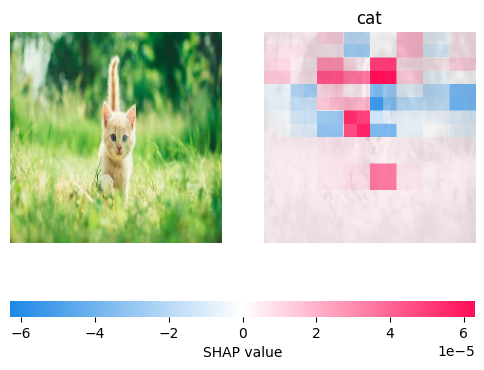

In [3]:
img_path = "/Users/ozgeyavuz/490/cat_or_dog_model_dataset/PetImages/test/cats/cat_119.jpg"
img_batch = load_preprocess_image(img_path)

print(f"Görüntü yüklendi ve işleme hazır: {img_path}")
print(img_batch.shape)  # (1, 224, 224, 3) olmalı

#-----Modeli saran fonksiyon-----
def f(X):
    X = X.copy()
    return model(X)

# Masker tanımla
masker = shap.maskers.Image("inpaint_telea", img_batch[0].shape)

# Explainer oluştur
explainer = shap.Explainer(f, masker, output_names=class_names)

# SHAP değerlerini hesapla
shap_values = explainer(img_batch, max_evals=1000, batch_size=50)

predictions = model.predict(img_batch)
#print(predictions)
predicted_class_index = 0 if predictions[0] < 0.5 else 1  # 0:cat, 1:dog
predicted_class_name = "cat" if predicted_class_index == 0 else "dog"
predicted_probability = predictions[0]
print(f"📈 Model Tahmini: {predicted_class_name} (Olasılık: {predicted_probability})")

# Görselleştir
shap.image_plot(shap_values)

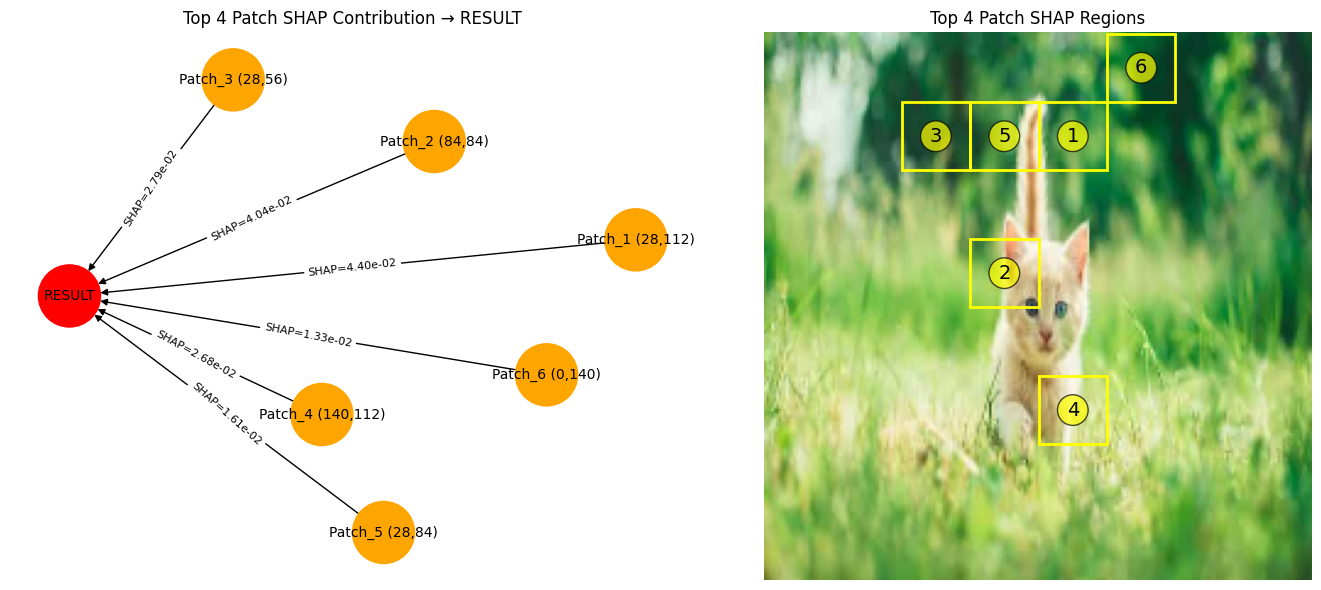

In [7]:
import matplotlib.pyplot as plt
import networkx as nx
import numpy as np

# SHAP değerlerini al (ör: shap_values.values[0] shape: (224, 224, 3, 1) veya (224, 224, 3))
shap_img = shap_values.values[0]
if shap_img.ndim == 4 and shap_img.shape[-1] == 1:
    shap_img = shap_img[..., 0]
elif shap_img.ndim == 5:
    shap_img = shap_img[0, ..., 0]

# Patch'lere bölelim (ör: 8x8 grid)
patch_size = 28  # 224/8 = 28
patch_shap_scores = []
for i in range(0, 224, patch_size):
    for j in range(0, 224, patch_size):
        patch = shap_img[i:i+patch_size, j:j+patch_size, :]
        score = np.abs(patch).sum()  # toplam katkı
        patch_shap_scores.append(((i, j), patch.sum()))

# En yüksek katkı yapan 4 patch'i seç
top_patches = sorted(patch_shap_scores, key=lambda x: x[1], reverse=True)[:6]

import matplotlib.pyplot as plt
import matplotlib.patches as patches
import networkx as nx

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# --- 1️⃣ Graph çizimi ---
G = nx.DiGraph()
G.add_node("RESULT", color='red')
for idx, ((i, j), score) in enumerate(top_patches):
    patch_name = f"Patch_{idx+1} ({i},{j})"
    G.add_node(patch_name, color='orange')
    G.add_edge(patch_name, "RESULT", label=f"SHAP={score:.2e}")

colors = [G.nodes[n].get('color', 'gray') for n in G.nodes]
pos = nx.spring_layout(G)
nx.draw(G, pos, with_labels=True, node_color=colors, node_size=2000, font_size=10, ax=axes[0])
edge_labels = nx.get_edge_attributes(G, 'label')
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_size=8, ax=axes[0])
axes[0].set_title("Top 4 Patch SHAP Contribution → RESULT")

# --- 2️⃣ Patch'li görsel ---
axes[1].imshow(img_batch[0])
for idx, ((i, j), score) in enumerate(top_patches):
    rect = patches.Rectangle((j, i), patch_size, patch_size, linewidth=2, edgecolor='yellow', facecolor='none')
    axes[1].add_patch(rect)
    axes[1].text(j + patch_size//2, i + patch_size//2, f'{idx+1}', color='black', fontsize=14, ha='center', va='center',
                 bbox=dict(facecolor='yellow', alpha=0.7, boxstyle='circle'))
axes[1].set_title("Top 4 Patch SHAP Regions")
axes[1].axis('off')

plt.tight_layout()
plt.show()

In [8]:
#Dog'a katkı yapan patchler (pozitif)
dog_patches = sorted(
    [p for p in patch_shap_scores if p[1] > 0],
    key=lambda x: x[1],
    reverse=True
)
print("Dog'a katkı yapan patchler (pozitif):" , dog_patches)

# Cat'e katkı yapan patchler (negatif)
cat_patches = sorted(
    [p for p in patch_shap_scores if p[1] <= 0],
    key=lambda x: x[1],  # en negatiften başlar
)

top_dog = dog_patches[:5]
top_cat = cat_patches[:5]

# Dog'a katkı yapan patchler toplamı
dog_total = sum([p[1] for p in dog_patches])
# Cat'e katkı yapan patchler toplamı
cat_total = sum([p[1] for p in cat_patches])
print("Dog'a katkı yapan patchler (pozitif):" , dog_total)
print("Cat'e katkı yapan patchler (negatif):" , cat_total)

Dog'a katkı yapan patchler (pozitif): [((28, 112), np.float64(0.04404855356551707)), ((84, 84), np.float64(0.0403874940238893)), ((28, 56), np.float64(0.027889855206012726)), ((140, 112), np.float64(0.026760888285934925)), ((28, 84), np.float64(0.016058393288403746)), ((0, 140), np.float64(0.01332149328663945)), ((56, 56), np.float64(0.01049646153114736)), ((28, 0), np.float64(0.00918071623891592)), ((56, 84), np.float64(0.008967330446466804)), ((28, 140), np.float64(0.00813025957904756)), ((140, 84), np.float64(0.006468775682151318)), ((0, 56), np.float64(0.005856853444129229)), ((140, 56), np.float64(0.00497503113001585)), ((0, 0), np.float64(0.004708929918706417)), ((140, 140), np.float64(0.004642183892428874)), ((112, 56), np.float64(0.00454989168792963)), ((112, 84), np.float64(0.00454989168792963)), ((0, 28), np.float64(0.00431988574564457)), ((0, 196), np.float64(0.004230810794979336)), ((28, 28), np.float64(0.004072247073054314)), ((28, 196), np.float64(0.003953652922064066)), 

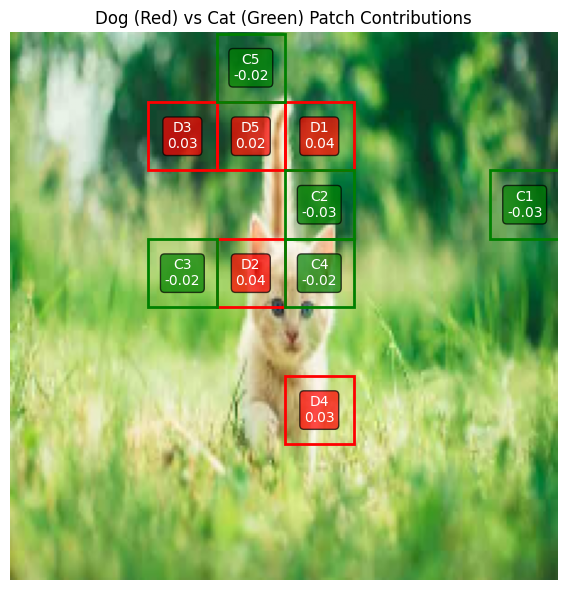

In [9]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches

fig, ax = plt.subplots(figsize=(6,6))

# Orijinal görüntüyü çiz
ax.imshow(img_batch[0])

# --- 1) DOG patchleri (pozitif → kırmızı) ---
for idx, ((i, j), score) in enumerate(top_dog):
    rect = patches.Rectangle(
        (j, i), patch_size, patch_size,
        linewidth=2, edgecolor='red', facecolor='none'
    )
    ax.add_patch(rect)

    ax.text(
        j + patch_size//2, i + patch_size//2,
        f"D{idx+1}\n{score:.2f}",
        color='white', fontsize=10, ha='center', va='center',
        bbox=dict(facecolor='red', alpha=0.7, boxstyle='round')
    )

# --- 2) CAT patchleri (negatif → yeşil) ---
for idx, ((i, j), score) in enumerate(top_cat):
    rect = patches.Rectangle(
        (j, i), patch_size, patch_size,
        linewidth=2, edgecolor='green', facecolor='none'
    )
    ax.add_patch(rect)

    ax.text(
        j + patch_size//2, i + patch_size//2,
        f"C{idx+1}\n{score:.2f}",
        color='white', fontsize=10, ha='center', va='center',
        bbox=dict(facecolor='green', alpha=0.7, boxstyle='round')
    )

ax.set_title("Dog (Red) vs Cat (Green) Patch Contributions")
ax.axis('off')

plt.tight_layout()
plt.show()


## multiple outputs

In [24]:
# img_paths = ["PetImages/test/cats/cat_446.jpg" , "PetImages/test/cats/cat_520.jpg", "PetImages/test/cats/cat_583.jpg", "PetImages/test/cats/cat_268.jpg"]
# for img_path in img_paths:
#     img_batch = load_preprocess_image(img_path)
#     shap_values = explainer(img_batch, max_evals=1000, batch_size=50)
#     shap_img = shap_values.values[0]
#     if shap_img.ndim == 4 and shap_img.shape[-1] == 1:
#         shap_img = shap_img[..., 0]
#     elif shap_img.ndim == 5:
#         shap_img = shap_img[0, ..., 0]

#     patch_size = 28
#     patch_shap_scores = []
#     for i in range(0, 224, patch_size):
#         for j in range(0, 224, patch_size):
#             patch = shap_img[i:i+patch_size, j:j+patch_size, :]
#             score = np.abs(patch).sum()
#             patch_shap_scores.append(((i, j), score))
#     top_patches = sorted(patch_shap_scores, key=lambda x: x[1], reverse=True)[:4]

#     fig, axes = plt.subplots(1, 2, figsize=(14, 6))
#     # Graph
#     G = nx.DiGraph()
#     G.add_node("RESULT", color='red')
#     for idx, ((i, j), score) in enumerate(top_patches):
#         patch_name = f"Patch_{idx+1} ({i},{j})"
#         G.add_node(patch_name, color='orange')
#         G.add_edge(patch_name, "RESULT", label=f"SHAP={score:.2e}")
#     colors = [G.nodes[n].get('color', 'gray') for n in G.nodes]
#     pos = nx.spring_layout(G)
#     nx.draw(G, pos, with_labels=True, node_color=colors, node_size=2000, font_size=10, ax=axes[0])
#     edge_labels = nx.get_edge_attributes(G, 'label')
#     nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_size=8, ax=axes[0])
#     axes[0].set_title("Top 4 Patch SHAP Contribution → RESULT")

#     # Görsel
#     axes[1].imshow(img_batch[0])
#     for idx, ((i, j), score) in enumerate(top_patches):
#         rect = patches.Rectangle((j, i), patch_size, patch_size, linewidth=2, edgecolor='yellow', facecolor='none')
#         axes[1].add_patch(rect)
#         axes[1].text(j + patch_size//2, i + patch_size//2, f'{idx+1}', color='black', fontsize=14, ha='center', va='center',
#                      bbox=dict(facecolor='yellow', alpha=0.7, boxstyle='circle'))
#     axes[1].set_title("Top 4 Patch SHAP Regions")
#     axes[1].axis('off')

#     plt.tight_layout()
#     plt.show()

In [25]:
# import tensorflow as tf
# import cv2
# import numpy as np


# model = tf.keras.models.load_model("/Users/ozgeyavuz/490/cat_or_dog_model_dataset/cats-vs-dogs-classifier-tensorflow2-fine-tuned-mobilenetv2-v1/mobilenetv2_catsdogs.keras")
# model.summary()

# def load_preprocess_image(img_path, target_size=(224,224)):
#     # OpenCV ile yükle ve RGB formatına çevir
#     img = cv2.imread(img_path)[..., ::-1]
#     img = cv2.resize(img, target_size)
#     img = np.expand_dims(img, axis=0)  # (1, H, W, C)
#     img = img / 255.0  # Normalize et
#     return img

In [26]:
# import shap
# class_names = ["cat", "dog"]

# img_path = "/Users/ozgeyavuz/490/cat_or_dog_model_dataset/PetImages/test/cats/cat_395.jpg"
# img_batch = load_preprocess_image(img_path)

# print(f"Görüntü yüklendi ve işleme hazır: {img_path}")
# print(img_batch.shape)  # (1, 224, 224, 3) olmalı

# import tensorflow as tf

# # Modeliniz dışarıdan 'model' değişkeni olarak erişilebilir durumda olmalı.

# import tensorflow as tf

# def get_logit_model(original_model):
#     """
#     Orijinal modelin ağırlıklarını koruyarak ve Sigmoid'i kaldırarak,
#     logit (lineer skor) çıktısı veren yeni bir Keras modeli oluşturur.
#     """
    
#     # 1. Modelin girişini al
#     input_tensor = original_model.input
    
#     # 2. Son Dense katmanına kadar olan tüm katmanların çıktısını al
#     # Bu, 'dropout' katmanının çıktısıdır (original_model.layers[-2].output).
#     previous_layer_output = original_model.layers[-2].output 
    
#     # 3. Son Dense katmanının ağırlıklarını al
#     final_dense_layer = original_model.layers[-1]
#     weights, biases = final_dense_layer.get_weights()
    
#     # 4. Yeni, AKTİVASYONSUZ Dense katmanının OBJESİNİ oluştur
#     # Bir katman objesi tanımlayın (henüz tensöre uygulanmadı):
#     new_dense_layer_obj = tf.keras.layers.Dense(
#         units=1, 
#         activation=None,  # Logit için aktivasyon yok
#         name='logit_output'
#     )
    
#     # 5. Yeni katmanı önceki çıktının üzerine uygulayın (Tensör objesini oluşturun)
#     logit_output_tensor = new_dense_layer_obj(previous_layer_output)
    
#     # 6. Yeni Logit Modelini oluştur
#     logit_model = tf.keras.Model(inputs=input_tensor, outputs=logit_output_tensor)
    
#     # 7. Model oluşturulduktan ve katmanlar hazırlandıktan sonra ağırlıkları ata
#     # Bu, yeni model oluşturulduktan hemen sonra yapılmalıdır.
#     # Yeni modeldeki son katman (index -1) oluşturduğumuz new_dense_layer_obj'dir.
#     logit_model.layers[-1].set_weights([weights, biases])
    
#     return logit_model

# # 🚀 Logit modelini oluşturun (Düzeltilmiş fonksiyonu kullanın)
# # logit_model = get_logit_model_fixed(model)

# # 🚀 Logit modelini oluşturun
# # !!! Bu satırı, 'model' değişkeni tanımlandıktan sonra çalıştırmanız gerekir.
# logit_model = get_logit_model(model) 

# #-----Modeli saran LOGIT fonksiyonu-----
# def f_logit(X):
#     X = X.copy()
#     return logit_model(X)

# # Masker tanımla
# masker = shap.maskers.Image("inpaint_telea", img_batch[0].shape)

# # Explainer oluştur
# explainer = shap.Explainer(f_logit, masker, output_names=class_names)

# # SHAP değerlerini hesapla
# shap_values = explainer(img_batch, max_evals=1000, batch_size=64)

# predictions = model.predict(img_batch)
# #print(predictions)
# predicted_class_index = 0 if predictions[0] < 0.5 else 1  # 0:cat, 1:dog
# predicted_class_name = "cat" if predicted_class_index == 0 else "dog"
# predicted_probability = predictions[0]
# print(f"📈 Model Tahmini: {predicted_class_name} (Olasılık: {predicted_probability})")

# shap_img = shap_values.values[0]
# if shap_img.ndim == 4 and shap_img.shape[-1] == 1:
#     shap_img = shap_img[..., 0]
# elif shap_img.ndim == 5:
#     shap_img = shap_img[0, ..., 0]

# # Patch'lere bölelim (ör: 8x8 grid)
# patch_size = 28  # 224/8 = 28
# patch_shap_scores = []
# for i in range(0, 224, patch_size):
#     for j in range(0, 224, patch_size):
#         patch = shap_img[i:i+patch_size, j:j+patch_size, :]
#         score = (patch).sum()  # toplam katkı
#         patch_shap_scores.append(((i, j), score))




In [27]:
# logit = logit_model.predict(img_batch)
# print(logit)
# from scipy.special import expit as sigmoid
# print(sigmoid(logit))

# #get sum of all shap values
# total_shap = sum([score for (_, score) in patch_shap_scores])
# print("Total SHAP value sum over all patches:", total_shap)

# # Eğer shap_values bir shap.Explanation objesi ise:
# # Tüm piksel/yama katkılarını toplayın (örnek 0 için)
# correct_sum = shap_values.values[0][..., 0].sum()

# # Ve beklenen değeri alın:
# base_value = shap_values.base_values[0]

# # Kontrol
# print("SHAP Base Value:", base_value)
# print("Correct Sum of SHAP values:", correct_sum)
# print("Base Value + Sum of SHAP:", base_value + correct_sum)
# print("Model Logit Çıktısı (Kontrol):", logit[0][0])



In [28]:
# print(shap_values.values[0][..., 0].shape)  # (1, 224, 224, 3)
# print(shap_values.base_values)   # logit mi yoksa sigmoid sonrası mı?
# print(np.sum(shap_values.values))  # toplam SHAP değeri


In [29]:
# Dog'a katkı yapan patchler (pozitif)
# dog_patches = sorted(
#     [p for p in patch_shap_scores if p[1] > 0],
#     key=lambda x: x[1],
#     reverse=True
# )
# print("Dog'a katkı yapan patchler (pozitif):" , dog_patches)

# # Cat'e katkı yapan patchler (negatif)
# cat_patches = sorted(
#     [p for p in patch_shap_scores if p[1] < 0],
#     key=lambda x: x[1],  # en negatiften başlar
# )

# top_dog = dog_patches[:5]
# top_cat = cat_patches[:5]

# # Dog'a katkı yapan patchler toplamı
# dog_total = sum([p[1] for p in dog_patches])
# # Cat'e katkı yapan patchler toplamı
# cat_total = sum([p[1] for p in cat_patches])
# print("Dog'a katkı yapan patchler (pozitif):" , dog_total)
# print("Cat'e katkı yapan patchler (negatif):" , cat_total)

In [30]:
# import numpy as np
# import matplotlib.pyplot as plt
# from scipy.special import expit  # sigmoid
# import tensorflow as tf

# def plot_shap_logit_diagnostic(model, dog_total, cat_total):
#     """
#     dog_total: pozitif SHAP toplamı (dog lehine)
#     cat_total: negatif SHAP toplamı (cat lehine)
#     """

#     # --- 1. Model son layer bias’ını çek ---
#     final_layer = model.layers[-1]
#     bias = final_layer.bias.numpy()[0]

#     # --- 2. SHAP toplamından logit katkısı ---
#     shap_logit = dog_total + cat_total  # dog total (+) + cat total (-)

#     # --- 3. Final logit ---
#     final_logit = shap_logit + bias

#     # --- 4. Probability ---
#     prob = expit(final_logit)

#     # --- 5. Plot ---
#     plt.figure(figsize=(10,6))
    
#     plt.bar(["Dog SHAP", "Cat SHAP", "Total SHAP (logit)", "Bias", "Final Logit"],
#             [dog_total, cat_total, shap_logit, bias, final_logit],
#             color=["red", "green", "blue", "gray", "purple"])

#     plt.title("How SHAP Scores + Model Bias Become Final Prediction")
#     plt.ylabel("Value")

#     plt.axhline(0, color="black", linewidth=0.8)

#     plt.text(4, final_logit, f"Sigmoid(final_logit)= {prob:.3f}",
#              fontsize=14, color="purple", ha="center", va="bottom")

#     plt.show()

#     print("\n--- DETAILS ---")
#     print(f"Dog SHAP total     : {dog_total}")
#     print(f"Cat SHAP total     : {cat_total}")
#     print(f"SHAP Logit Sum     : {shap_logit}")
#     print(f"Model Final Bias   : {bias}")
#     print(f"Final Logit        : {final_logit}")
#     print(f"Predicted Prob(Dog): {prob}")

# plot_shap_logit_diagnostic(model, dog_total, cat_total)

In [31]:
# shap_full = shap_values.values[0]  # (224,224,3)

# true_shap_sum = shap_full.sum()
# bias = model.layers[-1].bias.numpy()[0]
# z = true_shap_sum + bias
# p = expit(z)

# print("Gerçek SHAP logit:", z)
# print("Gerçek SHAP prob:", p)
# print("Model predict:", model.predict(img_batch))


In [32]:
# import matplotlib.pyplot as plt
# import matplotlib.patches as patches

# fig, ax = plt.subplots(figsize=(6,6))

# # Orijinal görüntüyü çiz
# ax.imshow(img_batch[0])

# # --- 1) DOG patchleri (pozitif → kırmızı) ---
# for idx, ((i, j), score) in enumerate(top_dog):
#     rect = patches.Rectangle(
#         (j, i), patch_size, patch_size,
#         linewidth=2, edgecolor='red', facecolor='none'
#     )
#     ax.add_patch(rect)

#     ax.text(
#         j + patch_size//2, i + patch_size//2,
#         f"D{idx+1}\n{score:.2f}",
#         color='white', fontsize=10, ha='center', va='center',
#         bbox=dict(facecolor='red', alpha=0.7, boxstyle='round')
#     )

# # --- 2) CAT patchleri (negatif → yeşil) ---
# for idx, ((i, j), score) in enumerate(top_cat):
#     rect = patches.Rectangle(
#         (j, i), patch_size, patch_size,
#         linewidth=2, edgecolor='green', facecolor='none'
#     )
#     ax.add_patch(rect)

#     ax.text(
#         j + patch_size//2, i + patch_size//2,
#         f"C{idx+1}\n{score:.2f}",
#         color='white', fontsize=10, ha='center', va='center',
#         bbox=dict(facecolor='green', alpha=0.7, boxstyle='round')
#     )

# ax.set_title("Dog (Red) vs Cat (Green) Patch Contributions")
# ax.axis('off')

# plt.tight_layout()
# plt.show()
